In [2]:
from huggingface_hub import login
login()

In [3]:
from datasets import load_dataset
dataset = load_dataset("ai4bharat/IndicVoices","marathi",split="valid", streaming=True)
print(next(iter(dataset)))

README.md:   0%|          | 0.00/32.2k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/112 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

{'audio_filepath': <datasets.features._torchcodec.AudioDecoder object at 0x7e7227095be0>, 'text': 'एकोणऐंशी सतरा अडुसष्ट अठ्ठ्याऐंशी शहाऐंशी तीन फोन नंबरवर ओ टी पी पाठवला गेला आहे कृपया लाभार्थी नाव अबोली कळसणेचे लस प्रमाणपत्र डाऊनलोड करण्यासाठी तो प्रविष्ट करा', 'duration': 17.865, 'lang': 'mr', 'samples': 285840, 'verbatim': 'एकोणऐंशी सतरा अडुसष्ट अठ्ठ्याऐंशी छ्याऐंशी तीन फोन नंबरवर ओटीपी पाठवला गेला आहे कृपया लाभार्थी नाव अबोली कळसणेचे लस प्रमाणपत्र डाऊनलोड करन्यासाटी तो प्रविष्ट करा', 'normalized': 'एकोणऐंशी सतरा अडुसष्ट अठ्ठ्याऐंशी शहाऐंशी तीन फोन नंबरवर ओ टी पी पाठवला गेला आहे कृपया लाभार्थी नाव अबोली कळसणेचे लस प्रमाणपत्र डाऊनलोड करण्यासाठी तो प्रविष्ट करा', 'speaker_id': 'S4258246100398868', 'scenario': 'Read', 'task_name': 'Umang Commands', 'gender': 'Female', 'age_group': '18-30', 'job_type': 'Unemployed', 'qualification': 'No Schooling', 'area': 'Urban', 'district': 'Akola', 'state': 'Maharashtra', 'occupation': 'House waif', 'verification_report': "{'decision': 'excellent',

In [4]:
sample = next(iter(dataset))

print(sample.keys())

dict_keys(['audio_filepath', 'text', 'duration', 'lang', 'samples', 'verbatim', 'normalized', 'speaker_id', 'scenario', 'task_name', 'gender', 'age_group', 'job_type', 'qualification', 'area', 'district', 'state', 'occupation', 'verification_report', 'unsanitized_verbatim', 'unsanitized_normalized'])


In [5]:
print(sample.keys())

dict_keys(['audio_filepath', 'text', 'duration', 'lang', 'samples', 'verbatim', 'normalized', 'speaker_id', 'scenario', 'task_name', 'gender', 'age_group', 'job_type', 'qualification', 'area', 'district', 'state', 'occupation', 'verification_report', 'unsanitized_verbatim', 'unsanitized_normalized'])


In [6]:
print(sample["audio_filepath"])

In [7]:
audio = sample["audio_filepath"]

print(type(audio))
print(dir(audio))

<class 'datasets.features._torchcodec.AudioDecoder'>
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_decoder', '_desired_sample_rate', '_hf_encoded', 'get_all_samples', 'get_samples_played_in_range', 'metadata', 'stream_index']


In [8]:
audio = sample["audio_filepath"]

samples = audio.get_all_samples()

print(type(samples))
print(samples)

<class 'torchcodec._frame.AudioSamples'>
AudioSamples:
  data (shape): torch.Size([1, 285840])
  pts_seconds: 0.0
  duration_seconds: 17.865
  sample_rate: 16000



In [9]:
print(sample["text"])

एकोणऐंशी सतरा अडुसष्ट अठ्ठ्याऐंशी शहाऐंशी तीन फोन नंबरवर ओ टी पी पाठवला गेला आहे कृपया लाभार्थी नाव अबोली कळसणेचे लस प्रमाणपत्र डाऊनलोड करण्यासाठी तो प्रविष्ट करा


In [10]:
import datasets

print(datasets.__version__)

4.0.0


In [11]:
from IPython.display import Audio

audio = sample["audio_filepath"].get_all_samples()

Audio(audio.data.squeeze().numpy(), rate=audio.sample_rate)

***EDA***

This tells us the datatype of every feature.

In [12]:
sample = next(iter(dataset))

for key, value in sample.items():
    print(f"{key:25} {type(value)}")

audio_filepath            <class 'datasets.features._torchcodec.AudioDecoder'>
text                      <class 'str'>
duration                  <class 'float'>
lang                      <class 'str'>
samples                   <class 'int'>
verbatim                  <class 'str'>
normalized                <class 'str'>
speaker_id                <class 'str'>
scenario                  <class 'str'>
task_name                 <class 'str'>
gender                    <class 'str'>
age_group                 <class 'str'>
job_type                  <class 'str'>
qualification             <class 'str'>
area                      <class 'str'>
district                  <class 'str'>
state                     <class 'str'>
occupation                <class 'str'>
verification_report       <class 'str'>
unsanitized_verbatim      <class 'str'>
unsanitized_normalized    <class 'str'>


In [13]:
import pandas as pd

records = []

for i, sample in enumerate(dataset):

    records.append({
        "text": sample["text"],
        "duration": sample["duration"],
        "lang": sample["lang"],
        "gender": sample["gender"],
        "age_group": sample["age_group"],
        "qualification": sample["qualification"],
        "occupation": sample["occupation"],
        "district": sample["district"],
        "state": sample["state"],
        "speaker_id": sample["speaker_id"]
    })

    if i == 999:
        break

df = pd.DataFrame(records)

In [14]:
df.head(25)

,text,duration,lang,gender,age_group,qualification,occupation,district,state,speaker_id
0,एकोणऐंशी सतरा अडुसष्ट अठ्ठ्याऐंशी शहाऐंशी तीन ...,17.865,mr,Female,18-30,No Schooling,House waif,Akola,Maharashtra,S4258246100398868
1,मी गेल्या चार महिन्यात कर्जाच्या हप्त्यावर कित...,5.193,mr,Female,45-60,Undergrad and Grad.,Clerical work,Pune,Maharashtra,S4258728400395589
2,नमस्कार बोला,1.703,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
3,हा हा,0.599,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
4,आम्हाला ते किराणामध्ये,1.978,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
5,आपलं होलसेल आहे ना म मार्केट,2.177,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
6,अच्छा अच्छा हा तेल तेल घ्यायचं होतं एक डबा,4.675,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
7,हा हा तर साखरचे आम्हाला प्राइस किती लागेल मग व...,6.329,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
8,हो का आणि तेलाचा डबा,1.655,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
9,हो का त्यामध्ये जे डिस्काउंट वगैरे,1.944,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   text           1000 non-null   object 
 1   duration       1000 non-null   float64
 2   lang           1000 non-null   object 
 3   gender         1000 non-null   object 
 4   age_group      1000 non-null   object 
 5   qualification  1000 non-null   object 
 6   occupation     1000 non-null   object 
 7   district       1000 non-null   object 
 8   state          1000 non-null   object 
 9   speaker_id     1000 non-null   object 
dtypes: float64(1), object(9)
memory usage: 78.3+ KB


In [16]:
df.describe(include = 'all')

,text,duration,lang,gender,age_group,qualification,occupation,district,state,speaker_id
count,1000,1000.00000,1000,1000,1000,1000,1000,1000,1000,1000
unique,827,NaN,1,2,4,4,58,21,1,95
top,हां,NaN,mr,Male,18-30,Undergrad and Grad.,Student,Sangli,Maharashtra,S4259005900353445
freq,37,NaN,1000,540,472,606,296,170,1000,51
mean,NaN,4.75925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,4.93161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.20400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.83275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2.75200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,7.35925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df.isnull().sum()

,0
text,0
duration,0
lang,0
gender,0
age_group,0
qualification,0
occupation,0
district,0
state,0
speaker_id,0


In [18]:
(df.isnull().mean()*100).sort_values(ascending=False)

,0
text,0.0
duration,0.0
lang,0.0
gender,0.0
age_group,0.0
qualification,0.0
occupation,0.0
district,0.0
state,0.0
speaker_id,0.0


In [19]:
df["text"].duplicated().sum()

np.int64(173)

In [20]:
df[df["text"].duplicated(keep=False)]

,text,duration,lang,gender,age_group,qualification,occupation,district,state,speaker_id
3,हा हा,0.599,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
10,हो का,0.430,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
12,हो का,0.365,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
32,हा हा,0.436,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
34,बरं बरं,0.625,mr,Male,60+,Undergrad and Grad.,Farmer,Amravati,Maharashtra,S4258725600395882
...,...,...,...,...,...,...,...,...,...,...
987,हो,0.296,mr,Male,30-45,Undergrad and Grad.,Private work,Akola,Maharashtra,S4259254800392900
994,हा,0.215,mr,Male,30-45,Undergrad and Grad.,Private work,Akola,Maharashtra,S4259254800392900
996,हा,0.333,mr,Male,30-45,Undergrad and Grad.,Private work,Akola,Maharashtra,S4259254800392900
997,हा,0.250,mr,Male,30-45,Undergrad and Grad.,Private work,Akola,Maharashtra,S4259254800392900


In [21]:
(df["text"].str.strip()=="").sum()

np.int64(0)

In [22]:
df["duration"].describe()

,duration
count,1000.00000
mean,4.75925
std,4.93161
min,0.20400
25%,0.83275
50%,2.75200
75%,7.35925
max,24.26300


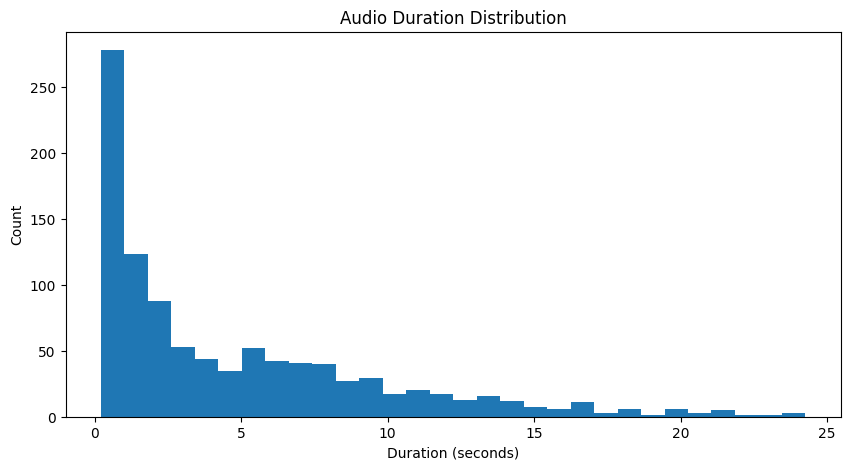

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["duration"], bins=30)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Audio Duration Distribution")
plt.show()

In [24]:
df["gender"].value_counts()

,count
gender,
Male,540
Female,460


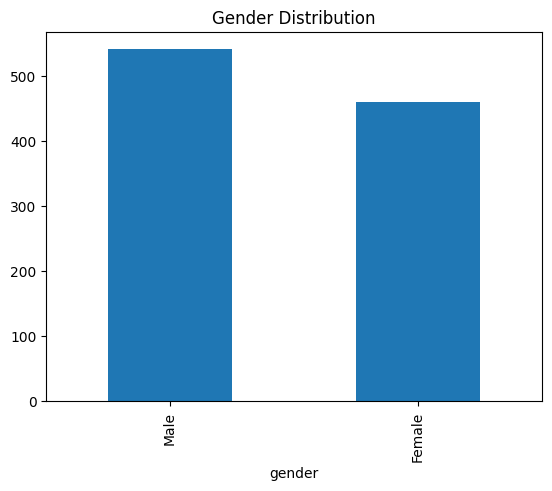

In [25]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

In [26]:
df["age_group"].value_counts()

,count
age_group,
18-30,472
30-45,236
45-60,214
60+,78


In [27]:
df["state"].value_counts().head(20)

,count
state,
Maharashtra,1000


In [28]:
df["word_count"] = df["text"].str.split().str.len()

df["word_count"].describe()

,word_count
count,1000.000000
mean,11.558000
std,11.916318
min,1.000000
25%,2.000000
50%,7.000000
75%,17.000000
max,66.000000


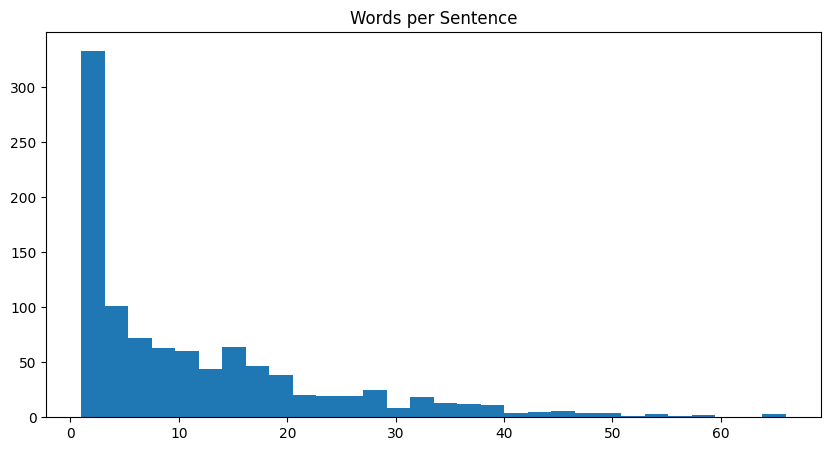

In [29]:
plt.figure(figsize=(10,5))
plt.hist(df["word_count"], bins=30)
plt.title("Words per Sentence")
plt.show()

In [30]:
df["char_count"] = df["text"].str.len()

df["char_count"].describe()

,char_count
count,1000.000000
mean,63.956000
std,69.372117
min,2.000000
25%,10.000000
50%,38.000000
75%,96.000000
max,414.000000


In [31]:
df.loc[df["char_count"].idxmax()]

,130
text,हां तर त्याच्यामुळं तुमचं बांधकाम किती आहे त्य...
duration,23.872
lang,mr
gender,Male
age_group,60+
qualification,Undergrad and Grad.
occupation,Writer and Translator
district,Satara
state,Maharashtra
speaker_id,S4259760100395762


In [32]:
df.loc[df["char_count"].idxmin()]

,74
text,जर
duration,0.736
lang,mr
gender,Female
age_group,18-30
qualification,Undergrad and Grad.
occupation,job
district,Akola
state,Maharashtra
speaker_id,S4258045600338732


In [33]:
df["speaker_id"].nunique()

95

In [34]:
df.groupby("speaker_id").size().describe()

,0
count,95.000000
mean,10.526316
std,11.447235
min,1.000000
25%,1.000000
50%,5.000000
75%,19.000000
max,51.000000


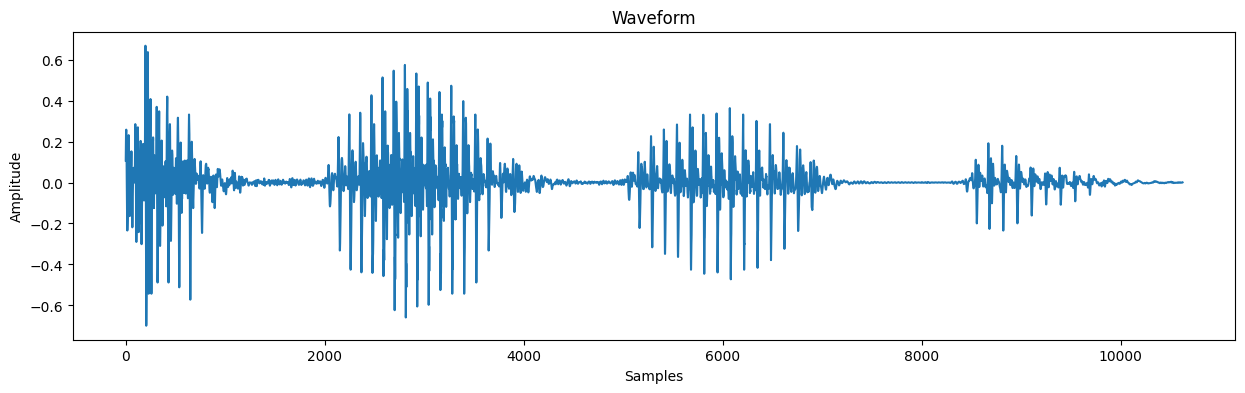

In [35]:
audio = sample["audio_filepath"].get_all_samples()

wave = audio.data.squeeze().numpy()

plt.figure(figsize=(15,4))
plt.plot(wave)
plt.title("Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [36]:
import random

idx = random.randint(0,999)

print(df.iloc[idx]["text"])

हो हो किंवा तुम्ही असेही करू शकता तुम्ही दुकानामध्ये येऊन व्हिजिट करा आणि इथे येऊन सर्व साड्या स्वतः बघून घ्या म्हणजे तुम्हाला स समोरूनच कळेल


In [37]:
from IPython.display import Audio

sample = next(iter(dataset))

print("Transcript:")
print(sample["text"])

audio = sample["audio_filepath"].get_all_samples()

Audio(
    audio.data.squeeze().numpy(),
    rate=audio.sample_rate
)

Transcript:
एकोणऐंशी सतरा अडुसष्ट अठ्ठ्याऐंशी शहाऐंशी तीन फोन नंबरवर ओ टी पी पाठवला गेला आहे कृपया लाभार्थी नाव अबोली कळसणेचे लस प्रमाणपत्र डाऊनलोड करण्यासाठी तो प्रविष्ट करा


In [38]:
from itertools import islice
samples = list(islice(dataset, 100))   # First 100 samples

In [41]:
import random
from IPython.display import Audio

sample = random.choice(samples)

print(sample["text"])

audio = sample["audio_filepath"].get_all_samples( )

Audio(
    audio.data.squeeze().numpy(),
    rate=audio.sample_rate
)

नाही तेच सांगतो तुम्हाला तर त्याच्याने झालं नाही आठवडाभर थांबा जर त्याच्याने झालं नाही त्रास व्हायला लागला तर आपल्याला रूट कॅनल करायला लागेल त्याचा दोन दाढेचं हां
